,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


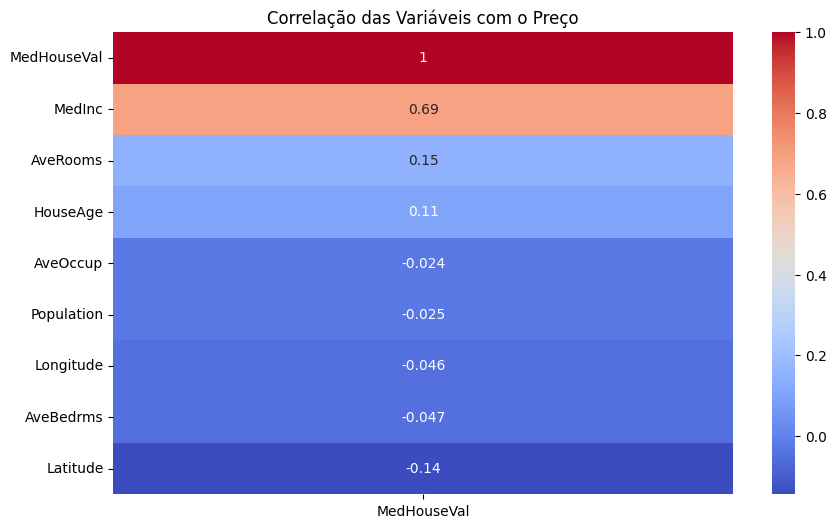

Pesos (Coeficientes) da Regressão Linear:
     Variavel      Peso
3   AveBedrms  0.783145
0      MedInc  0.448675
1    HouseAge  0.009724
4  Population -0.000002
5    AveOccup -0.003526
2    AveRooms -0.123323
6    Latitude -0.419792
7   Longitude -0.433708 

MAE: 0.5332
RMSE: 0.7456
R² Score: 0.5758


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Carga e Exploração Rápida
california = fetch_california_housing(as_frame=True)
df = california.frame

display(df.head(10))

# Mostrando a correlação com o preço (MedHouseVal)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr()[['MedHouseVal']].sort_values(by='MedHouseVal', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlação das Variáveis com o Preço")
plt.show()

# 2. Divisão dos Dados
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Treinamento
modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

# Analisando o peso que a máquina deu para as variáveis
coeficientes = pd.DataFrame({'Variavel': X.columns, 'Peso': modelo_linear.coef_})
print("Pesos (Coeficientes) da Regressão Linear:")
print(coeficientes.sort_values(by='Peso', ascending=False), "\n")

# 4. Avaliação
y_pred = modelo_linear.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Intercepto (Beta 0): 0.5473
Coeficiente (Beta 1): 0.3907


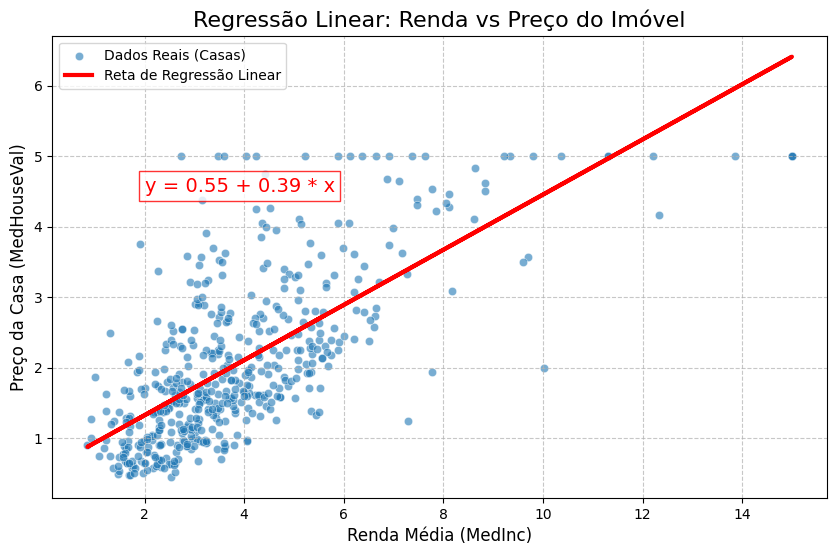

In [ ]:
# Para uma visualização limpa, vamos usar apenas uma amostra de 500 casas
# e a variável que tem a melhor correlação linear: Renda Média (MedInc)
df_amostra = df.sample(500, random_state=42)

X = df_amostra[['MedInc']]  # Variável Independente (Renda)
y = df_amostra['MedHouseVal'] # Variável Dependente (Preço)

# 2. Treinando o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# 3. Extraindo os coeficientes matemáticos da reta
beta_0 = modelo.intercept_  # Onde cruza o eixo Y
beta_1 = modelo.coef_[0]    # A inclinação da reta

print(f"Intercepto (Beta 0): {beta_0:.4f}")
print(f"Coeficiente (Beta 1): {beta_1:.4f}")

# 4. Criando o gráfico
plt.figure(figsize=(10, 6))

# Plotando os pontos reais (Scatter Plot)
sns.scatterplot(x=df_amostra['MedInc'], y=df_amostra['MedHouseVal'], alpha=0.6, label='Dados Reais (Casas)')

# Plotando a Reta de Regressão
# A reta é gerada prevendo os valores de X com o modelo treinado
y_pred = modelo.predict(X)
plt.plot(df_amostra['MedInc'], y_pred, color='red', linewidth=3, label='Reta de Regressão Linear')

# 5. Adicionando a Equação no Gráfico
equacao = f"y = {beta_0:.2f} + {beta_1:.2f} * x"
plt.text(x=2, y=4.5, s=equacao, fontsize=14, color='red',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

plt.title('Regressão Linear: Renda vs Preço do Imóvel', fontsize=16)
plt.xlabel('Renda Média (MedInc)', fontsize=12)
plt.ylabel('Preço da Casa (MedHouseVal)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\h'
<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_901/1807874409.py:51: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel('Previsões do Modelo ($\hat{y}$)')
/tmp/ipykernel_901/1807874409.py:52: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_ylabel('Resíduos / Erros ($y - \hat{y}$)')


1. Coeficiente de Correlação de Pearson: 0.7006
   (Valores longe de 0 e próximos de 1 ou -1 provam linearidade comercial)



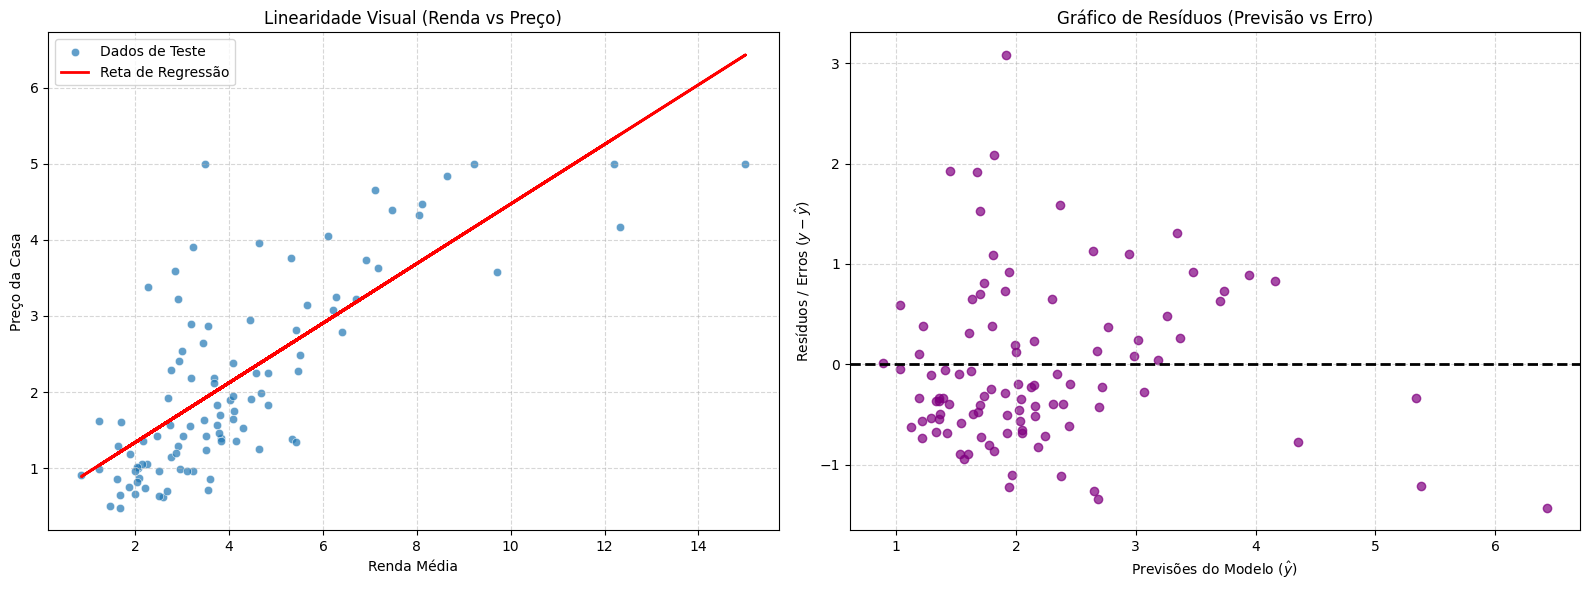

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Carregar os dados e extrair uma amostra para visualização limpa
california = fetch_california_housing(as_frame=True)
df = california.frame
df_amostra = df.sample(500, random_state=42)

X = df_amostra[['MedInc']]  # Renda Média
y = df_amostra['MedHouseVal'] # Preço da Casa

# =====================================================================
# PROVA 1 (ANTES DO TREINO): CORRELAÇÃO DE PEARSON E DISPERSÃO
# =====================================================================
correlacao = df_amostra['MedInc'].corr(df_amostra['MedHouseVal'])
print(f"1. Coeficiente de Correlação de Pearson: {correlacao:.4f}")
print("   (Valores longe de 0 e próximos de 1 ou -1 provam linearidade comercial)\n")

# =====================================================================
# PROVA 2 (DEPOIS DO TREINO): ANÁLISE DE RESÍDUOS
# =====================================================================
# Treinar o modelo para gerar as previsões e os erros
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
residuos = y_test - y_pred # O erro real: Valor Real - Valor Previsto

# Criar a figura com dois gráficos lado a lado para mostrar aos alunos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico da Esquerda: A Nuvem Original com a Reta
sns.scatterplot(x=X_test['MedInc'], y=y_test, alpha=0.7, ax=axes[0], label='Dados de Teste')
axes[0].plot(X_test['MedInc'], y_pred, color='red', linewidth=2, label='Reta de Regressão')
axes[0].set_title('Linearidade Visual (Renda vs Preço)', fontsize=12)
axes[0].set_xlabel('Renda Média')
axes[0].set_ylabel('Preço da Casa')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico da Direita: O Gráfico de Resíduos (A Prova Estatística)
axes[1].scatter(y_pred, residuos, color='purple', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2) # Linha do erro zero
axes[1].set_title('Gráfico de Resíduos (Previsão vs Erro)', fontsize=12)
axes[1].set_xlabel('Previsões do Modelo ($\hat{y}$)')
axes[1].set_ylabel('Resíduos / Erros ($y - \hat{y}$)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
import numpy as np

# 1. Preparando os dados
df_amostra = df.sample(500, random_state=42)
X_multiple = df_amostra[['MedInc', 'HouseAge']]
y = df_amostra['MedHouseVal']

# 2. Treinando o modelo
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_multiple, y)

b0 = modelo_multiple.intercept_
b1, b2 = modelo_multiple.coef_

# 3. Criando a grade para o plano de regressão
x_range = np.linspace(df_amostra['MedInc'].min(), df_amostra['MedInc'].max(), 20)
y_range = np.linspace(df_amostra['HouseAge'].min(), df_amostra['HouseAge'].max(), 20)
x_surf, y_surf = np.meshgrid(x_range, y_range)
z_surf = b0 + b1 * x_surf + b2 * y_surf

# 4. Criando o gráfico interativo com Plotly
fig = go.Figure()

# Adicionando os pontos reais
fig.add_trace(go.Scatter3d(
    x=df_amostra['MedInc'],
    y=df_amostra['HouseAge'],
    z=df_amostra['MedHouseVal'],
    mode='markers',
    marker=dict(size=4, color='blue', opacity=0.6),
    name='Dados Reais'
))

# Adicionando o plano de regressão
fig.add_trace(go.Surface(
    x=x_range,
    y=y_range,
    z=z_surf,
    colorscale='Reds',
    opacity=0.5,
    name='Plano de Regressão',
    showscale=False
))

# Configurações de layout
fig.update_layout(
    title='Regressão Linear Múltipla 3D (Interativo)',
    scene=dict(
        xaxis_title='Renda (MedInc)',
        yaxis_title='Idade (HouseAge)',
        zaxis_title='Preço (MedHouseVal)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()